STEP 1 – Load your CSV file
---------------------------


Enter the CSV file name or path (e.g. data.csv):  soldiers2023.csv



File 'soldiers2023.csv' successfully loaded.

Available columns in the dataset:
['time', 'Wykleci', 'AK', 'NSZ']

STEP 2 – Choose date and value columns
--------------------------------------


Enter the column name that contains the dates:  time
Enter the column name that contains the numeric values:  Wykleci



Converting the date column and cleaning the data...

Time series after cleaning has 239 observations.
Time span: from 2004-01-01 to 2023-11-01.

STEP 3 – Plotting the original time series
------------------------------------------


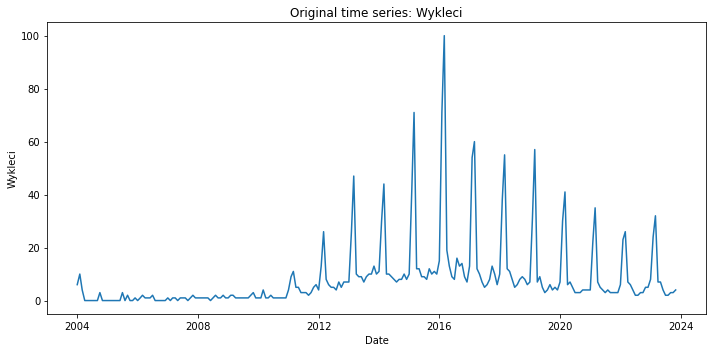


STEP 4 – Choose your 'critical / causal moment'
------------------------------------------------
You can enter an approximate date for the critical moment, e.g. '2011-03-01', '2016-01-01' or '2015-06-15'.
The script will snap your answer to the nearest observed time point in the series.


Enter the critical (causal) date:  2011-03-01



You entered: 2011-03-01
The nearest observed date in the series is: 2011-03-01


Use this observed date as the causal moment? (y/n):  y



STEP 5 – Building the CausalImpact model
-----------------------------------------
Pre-intervention period (index positions): [0, 85]
Post-intervention period (index positions): [86, 238]


/home/wiwern/anaconda3/lib/python3.8/site-packages/statsmodels/base/optimizer.py:17: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score. The list of unsupported keyword arguments passed include: nseasons, standardize. After release 0.14, this will raise.
  warnings.warn(



STEP 6 – Numerical summary from CausalImpact
---------------------------------------------
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    12.45              1905.0
Prediction (s.d.)         1.29 (0.28)        196.91 (43.54)
95% CI                    [0.7, 1.82]        [107.09, 277.75]

Absolute effect (s.d.)    11.16 (0.28)       1708.09 (43.54)
95% CI                    [10.64, 11.75]     [1627.25, 1797.91]

Relative effect (s.d.)    867.46% (22.11%)   867.46% (22.11%)
95% CI                    [826.41%, 913.08%] [826.41%, 913.08%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))

Detailed report:
----------------
Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 12.45. By contrast, in the absence of an
intervention, we would have expected an

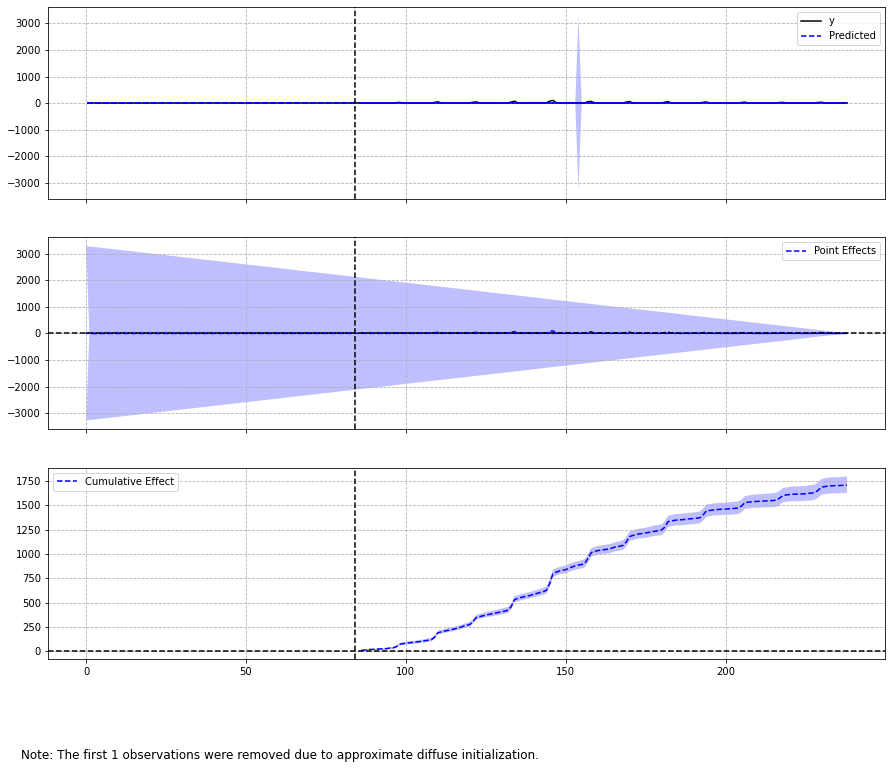


STEP 8 – Interpretation (template in English)
---------------------------------------------

Selected causal moment (observed date): 2011-03-01
Time series variable: Wykleci
Number of pre-intervention observations: 86
Number of post-intervention observations: 153

The script could not automatically extract the detailed effect estimates
from 'impact.summary_data'. Please inspect the numerical summary and
the report above to evaluate the size and significance of the effect.

INTERPRETATION TEMPLATE (for your historical analysis)
------------------------------------------------------
1. Before the selected causal moment, the model learns the typical level,
   variability and trend of the series. This corresponds to the 'historical
   baseline' before the event you consider important.

2. Using only the pre-intervention period, CausalImpact constructs a
   hypothetical counterfactual trajectory: how the series would have
   continued if the critical moment had not taken place.

3. The met

In [3]:
# Time series analysis with a "causal moment" using CausalImpact
# --------------------------------------------------------------
# This notebook:
# 1. Asks for a CSV file with a time series.
# 2. Asks for the date column and the numeric value column.
# 3. Asks for a user-defined "critical / causal moment" (approximate date).
# 4. Snaps this date to the nearest observed time point in the data.
# 5. Uses the CausalImpact package to estimate the impact of this moment
#    on the trend of the series.
# 6. Prints an English interpretation of the results and briefly connects
#    the method to Werner's idea of a "causal moment" in historical time-series research.

import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Try to import CausalImpact
try:
    from causalimpact import CausalImpact
except ImportError:
    print(
        "The 'causalimpact' package is not installed.\n"
        "Install it first, for example:\n\n"
        "  pip install causalimpact\n\n"
        "Then re-run this notebook."
    )
    raise SystemExit

plt.rcParams["figure.figsize"] = (10, 5)

print("STEP 1 – Load your CSV file")
print("---------------------------")

while True:
    csv_path = input("Enter the CSV file name or path (e.g. data.csv): ").strip()

    try:
        df = pd.read_csv(csv_path)
        print(f"\nFile '{csv_path}' successfully loaded.")
        break
    except FileNotFoundError:
        print(f"\nFile not found: {csv_path}")
        print("Please check that the file exists and try again.\n")
    except Exception as e:
        print(f"\nUnexpected error while reading the file: {e}")
        print("Please fix the problem (e.g. encoding, separator) and try again.\n")

print("\nAvailable columns in the dataset:")
print(list(df.columns))

print("\nSTEP 2 – Choose date and value columns")
print("--------------------------------------")

# Ask for date column
while True:
    date_col = input("Enter the column name that contains the dates: ").strip()
    if date_col in df.columns:
        break
    else:
        print(f"Column '{date_col}' not found. Please choose one of: {list(df.columns)}")

# Ask for value column
while True:
    value_col = input("Enter the column name that contains the numeric values: ").strip()
    if value_col in df.columns:
        break
    else:
        print(f"Column '{value_col}' not found. Please choose one of: {list(df.columns)}")

print("\nConverting the date column and cleaning the data...")

# Convert dates and numeric values, drop rows where conversion failed
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df[value_col] = pd.to_numeric(df[value_col], errors="coerce")

ts_df = df[[date_col, value_col]].dropna()
ts_df = ts_df.sort_values(date_col)
ts_df = ts_df.set_index(date_col)

if len(ts_df) < 10:
    print(
        "\nWarning: The cleaned time series has fewer than 10 observations.\n"
        "CausalImpact may not work well with such a short series."
    )

print(f"\nTime series after cleaning has {len(ts_df)} observations.")
print(f"Time span: from {ts_df.index.min().date()} to {ts_df.index.max().date()}.")






print("\nSTEP 3 – Plotting the original time series")
print("------------------------------------------")

# Convert index and values to NumPy arrays to avoid pandas/matplotlib issues
x = ts_df.index.to_numpy()
y = ts_df[value_col].to_numpy()

plt.figure()
plt.plot(x, y)
plt.title(f"Original time series: {value_col}")
plt.xlabel("Date")
plt.ylabel(value_col)
plt.tight_layout()
plt.show()

# Ask for the critical / causal moment
print("\nSTEP 4 – Choose your 'critical / causal moment'")
print("------------------------------------------------")
print(
    "You can enter an approximate date for the critical moment, e.g. '2011-03-01', "
    "'2016-01-01' or '2015-06-15'.\n"
    "The script will snap your answer to the nearest observed time point in the series."
)

while True:
    user_moment_str = input("Enter the critical (causal) date: ").strip()
    user_moment = pd.to_datetime(user_moment_str, errors="coerce")

    if pd.isna(user_moment):
        print("Could not parse this as a date. Please try again (e.g. 2011-03-01).")
        continue

    # Find the nearest observed timestamp in the series
    idx_pos = ts_df.index.get_indexer([user_moment], method="nearest")[0]
    crit_date = ts_df.index[idx_pos]

    print(f"\nYou entered: {user_moment.date()}")
    print(f"The nearest observed date in the series is: {crit_date.date()}")

    confirm = input("Use this observed date as the causal moment? (y/n): ").strip().lower()
    if confirm == "y":
        break
    else:
        print("OK, let's try again.\n")

# STEP 5 – Building the CausalImpact model
print("\nSTEP 5 – Building the CausalImpact model")
print("-----------------------------------------")

# Reset index to integer positions for CausalImpact
y = ts_df[value_col].reset_index(drop=True)
data_ci = pd.DataFrame({"y": y})

# Make sure we use plain Python ints, not numpy.int64
crit_idx = int(idx_pos)
n = int(len(data_ci))

if crit_idx <= 1 or crit_idx >= n - 2:
    print(
        "\nWarning: The critical moment is too close to the beginning or end "
        "of the series.\nCausalImpact needs a reasonable number of pre- and "
        "post-intervention observations."
    )

pre_period = [int(0), int(crit_idx - 1)]
post_period = [int(crit_idx), int(n - 1)]

print(f"Pre-intervention period (index positions): {pre_period}")
print(f"Post-intervention period (index positions): {post_period}")

# Run CausalImpact
impact = CausalImpact(data_ci, pre_period, post_period)



print("\nSTEP 6 – Numerical summary from CausalImpact")
print("---------------------------------------------")
print(impact.summary())  # short numeric summary

print("\nDetailed report:")
print("----------------")
print(impact.summary(output="report"))

# Plot the CausalImpact results
print("\nSTEP 7 – Plotting CausalImpact results")
print("--------------------------------------")
impact.plot()
plt.show()

# STEP 8 – Automatic textual interpretation (in English)
print("\nSTEP 8 – Interpretation (template in English)")
print("---------------------------------------------")

# Try to extract some numbers from the summary_data, if available
avg_effect = None
rel_effect = None
p_value = None

try:
    summary_df = impact.summary_data  # may or may not exist depending on version
    # Look for a row that contains "average"
    # and typical column names such as 'avg' and 'rel'
    if "average" in summary_df.index:
        row = summary_df.loc["average"]
        avg_effect = row.get("avg", None)
        rel_effect = row.get("rel", None)
        p_value = row.get("p", None)
except Exception:
    # If anything goes wrong, we just skip automatic extraction.
    pass

print(f"\nSelected causal moment (observed date): {crit_date.date()}")
print(f"Time series variable: {value_col}")
print(f"Number of pre-intervention observations: {pre_period[1] - pre_period[0] + 1}")
print(f"Number of post-intervention observations: {post_period[1] - post_period[0] + 1}\n")

if avg_effect is not None and rel_effect is not None and p_value is not None:
    print("According to the CausalImpact summary, the estimated average effect")
    print(f"of the intervention (over the post-intervention period) is about {avg_effect:.3f}")
    print(f"which corresponds to a relative change of approximately {rel_effect*100:.1f}%.\n")
    print(
        "The posterior tail-area probability (similar to a p-value) is "
        f"{p_value:.3f}.\n"
        "A small value (for example, below 0.05) suggests that it is unlikely\n"
        "that the observed post-intervention pattern could be explained purely\n"
        "by the pre-intervention trend and random noise."
    )
else:
    print(
        "The script could not automatically extract the detailed effect estimates\n"
        "from 'impact.summary_data'. Please inspect the numerical summary and\n"
        "the report above to evaluate the size and significance of the effect."
    )

print("\nINTERPRETATION TEMPLATE (for your historical analysis)")
print("------------------------------------------------------")
print(
    "1. Before the selected causal moment, the model learns the typical level,\n"
    "   variability and trend of the series. This corresponds to the 'historical\n"
    "   baseline' before the event you consider important.\n\n"
    "2. Using only the pre-intervention period, CausalImpact constructs a\n"
    "   hypothetical counterfactual trajectory: how the series would have\n"
    "   continued if the critical moment had not taken place.\n\n"
    "3. The method then compares this hypothetical series with the real\n"
    "   post-intervention observations. The more they diverge in a systematic\n"
    "   way, the stronger the evidence that your chosen moment changed the\n"
    "   long-term trajectory of the process.\n\n"
    "4. In the context of historical research (see Werner, 2024), this is an\n"
    "   operationalisation of the 'causal moment' idea: we treat a specific\n"
    "   date or short time window as a potential turning point in the time\n"
    "   series and test whether it really produces a durable change in the\n"
    "   trend, beyond short-term fluctuations or seasonal effects.\n\n"
    "5. Substantive interpretation still requires historical reasoning. You\n"
    "   have to link the detected change in the series to concrete events,\n"
    "   policies or processes, and discuss alternative explanations for the\n"
    '   observed break in the trajectory (\"what else could have caused it?\").'
)

print("\nYou can now write your own historical interpretation in a separate Markdown cell.")
